In [158]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Videos\Real World ML Projects\loan-risk-prediction\data\raw\loan_approval_dataset.csv")

df.columns = df.columns.str.strip()

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [159]:
df.drop("loan_id", axis=1, inplace=True)

In [160]:
df["total_assets"] = (
    df["residential_assets_value"]
    + df["commercial_assets_value"]
    + df["luxury_assets_value"]
    + df["bank_asset_value"]
)

In [161]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,50700000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,17000000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,57700000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,52700000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,55000000


In [162]:
# loan to income ratio 
df["loan_to_income_ratio"] = df["loan_amount"] / df["income_annum"]

In [163]:
# total assets to loan amount 
df["asset_to_loan_ratio"] = df["total_assets"] / df["loan_amount"]

In [164]:
# income per dependent 
df["income_per_dependent"] = df["income_annum"] / (df["no_of_dependents"] + 1)

In [165]:
df.to_csv("../data/processed/loan_processed.csv", index=False)

In [166]:
df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

### Here we have imbalanced dataset so we perform smote to balance them

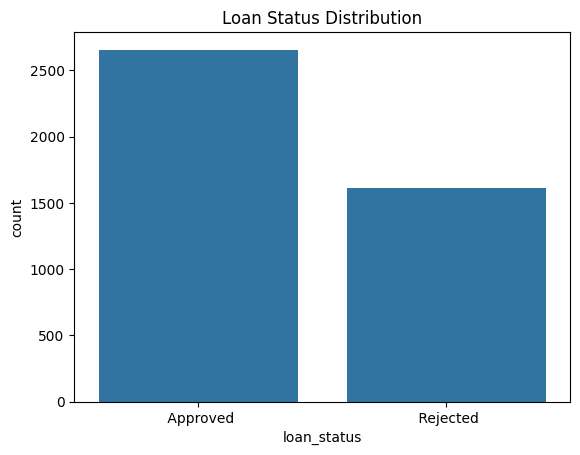

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()

### Fix Column Spacing Problem 

In [168]:
df["loan_status"].unique()

array([' Approved', ' Rejected'], dtype=object)

In [169]:
df["loan_status"] = df["loan_status"].str.strip()

In [170]:
df["loan_status"].unique()

array(['Approved', 'Rejected'], dtype=object)

In [171]:
df["loan_status"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

In [172]:
df["loan_status"].value_counts()

loan_status
1    2656
0    1613
Name: count, dtype: int64

In [173]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets,loan_to_income_ratio,asset_to_loan_ratio,income_per_dependent
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,50700000,3.114583,1.695652,3.200000e+06
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,17000000,2.975610,1.393443,4.100000e+06
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,57700000,3.263736,1.942761,2.275000e+06
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,52700000,3.743902,1.716612,2.050000e+06
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,55000000,2.469388,2.272727,1.633333e+06


In [174]:
df["education"] = df["education"].str.strip()
df['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [175]:
df["education"] = df["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

In [176]:
df["self_employed"] = df["self_employed"].str.strip()

In [177]:
df["self_employed"] = df["self_employed"].map({
    "Yes": 1,
    "No": 0
})

In [178]:
df['self_employed'].unique()

array([0, 1])

In [179]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [180]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [181]:
y_train.value_counts()

loan_status
1    2125
0    1290
Name: count, dtype: int64

In [182]:
X_train.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,total_assets,loan_to_income_ratio,asset_to_loan_ratio,income_per_dependent
1877,4,1,0,4800000,14300000,6,795,5900000,0,11100000,2600000,19600000,2.979167,1.370629,9.600000e+05
1729,3,1,1,5800000,16700000,18,633,8100000,8400000,14700000,3700000,34900000,2.879310,2.089820,1.450000e+06
164,2,1,1,8100000,22300000,18,737,22300000,12600000,27000000,7300000,69200000,2.753086,3.103139,2.700000e+06
2298,2,0,1,4400000,13900000,6,810,13200000,4200000,15000000,5200000,37600000,3.159091,2.705036,1.466667e+06
2461,5,1,0,6500000,24800000,8,779,7000000,9600000,15700000,8800000,41100000,3.815385,1.657258,1.083333e+06


In [183]:
y_train.head()

1877    1
1729    1
164     1
2298    1
2461    1
Name: loan_status, dtype: int64

In [184]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [185]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [187]:
X_train_balanced

array([[ 0.89071783,  0.99853694, -1.00852831, ..., -0.00876478,
        -1.33409393, -0.54803372],
       [ 0.30110717,  0.99853694,  0.99154381, ..., -0.17641697,
        -0.22032157, -0.30459362],
       [-0.28850349,  0.99853694,  0.99154381, ..., -0.38833864,
         1.34895047,  0.31642702],
       ...,
       [-0.67470398, -1.0014652 ,  0.99154381, ...,  1.11102532,
        -0.77699933, -0.47450364],
       [ 0.30110717, -1.0014652 , -1.00852831, ..., -1.65125369,
         1.64056579, -0.87622574],
       [-0.87811415,  0.99853694,  0.99154381, ..., -1.4345817 ,
         1.9854664 ,  0.69880772]], shape=(4250, 15))

In [ ]:
y_train_balanced.value_counts()

loan_status
1    2125
0    2125
Name: count, dtype: int64

In [ ]:
print(X_train_balanced.shape)
print(y_train_balanced.shape)

(4250, 15)
(4250,)


In [189]:
processed_df = pd.concat(
    [pd.DataFrame(X_train_balanced), pd.Series(y_train_balanced, name="loan_status")],
    axis=1
)

processed_df.to_csv("../data/processed/train_balanced.csv", index=False)

In [190]:
test_df = pd.concat(
    [pd.DataFrame(X_test_scaled), pd.Series(y_test, name="loan_status")],
    axis=1
)

test_df.to_csv("../data/processed/test_data.csv", index=False)

In [191]:
import pickle

pickle.dump(scaler, open("../models/scaler.pkl", "wb"))